# ML: prediccion de cierre ganado de oportunidad

Stretch goal. Entrena un clasificador sobre `gold.fact_opportunity` para predecir `is_won`, y lo persiste para Streamlit.

## 1. Features -- y por que se excluyen otras

**Se usan:** `industry`, `country`, `annual_revenue`, `employees` (de `dim_account`), `amount` (tamano del trato, conocido al crear la oportunidad).

**Se filtra a oportunidades cerradas** (`NOT is_open`) -- no tiene sentido predecir el resultado de un trato que todavia esta en curso, esa fila no tiene una etiqueta real todavia.

**Se excluyen a proposito:** `stage` (`stage = 'won'` es literalmente la definicion de `is_won` -- usarlo seria filtracion trivial), `is_lost`/`is_open` (se derivan de `stage`), y `sales_cycle_days` (solo se conoce *despues* de cerrar el trato -- no esta disponible en el momento en que se querria predecir).

In [1]:
import sys, os
sys.path.append("/home/jovyan/work/src")

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

from utils.db import get_engine

engine = get_engine()
MODELS_ROOT = Path(os.environ.get("MODELS_ROOT", "/home/jovyan/work/models"))
MODELS_ROOT.mkdir(parents=True, exist_ok=True)

BLUE = "#2a78d6"

In [2]:
df = pd.read_sql("""
    SELECT o.is_won,
           a.industry, a.country, a.annual_revenue, a.employees,
           o.amount
    FROM gold.fact_opportunity o
    JOIN gold.dim_account a ON a.account_id = o.account_id
    WHERE NOT o.is_open
""", engine)

print("Filas (oportunidades cerradas):", len(df))
print("Balance de clases (is_won):")
print(df["is_won"].value_counts(normalize=True).round(3))

Filas (oportunidades cerradas): 779
Balance de clases (is_won):
is_won
True     0.611
False    0.389
Name: proportion, dtype: float64


## 2. Split, pipeline y entrenamiento

In [3]:
CATEGORICAL = ["industry", "country"]
NUMERIC = ["annual_revenue", "employees", "amount"]

X = df[CATEGORICAL + NUMERIC]
y = df["is_won"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

pipeline = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced", random_state=42)),
])

pipeline.fit(X_train, y_train)
print("Entrenado.")

Entrenado.


## 3. Evaluacion

              precision    recall  f1-score   support

        lost       0.41      0.39      0.40        61
         won       0.62      0.63      0.62        95

    accuracy                           0.54       156
   macro avg       0.51      0.51      0.51       156
weighted avg       0.54      0.54      0.54       156

ROC-AUC: 0.507


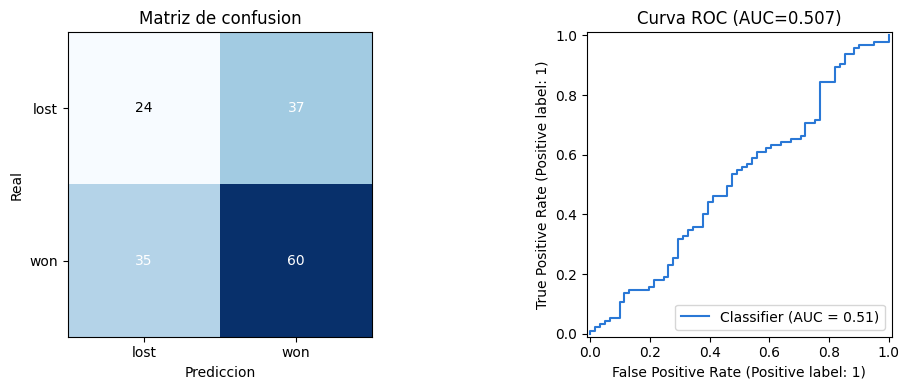

In [4]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["lost", "won"]))
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["lost", "won"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["lost", "won"])
axes[0].set_xlabel("Prediccion"); axes[0].set_ylabel("Real"); axes[0].set_title("Matriz de confusion")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max()/2 else "black")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color=BLUE)
axes[1].set_title(f"Curva ROC (AUC={auc:.3f})")
plt.tight_layout()
plt.show()

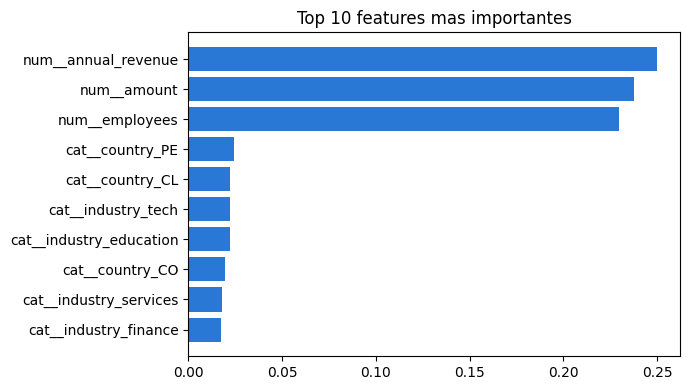

In [5]:
feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_
imp = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp["feature"], imp["importance"], color=BLUE)
ax.set_title("Top 10 features mas importantes")
plt.tight_layout()
plt.show()

## 4. Persistir el modelo

## 3.1 Hallazgo honesto: el modelo no supera el azar

**ROC-AUC ≈ 0.51**, igual que el modelo de churn. Consistente con `notebooks/analysis/01_insights.ipynb`, donde el win rate por industria variaba 57%-69% -- una dispersion mas ancha que la de churn, pero probablemente explicada por el tamano de muestra por industria (300-570 oportunidades cada una), no por una relacion real y aprendible entre `industry`/`annual_revenue`/`amount` y el resultado.

**Conclusion:** mismo caso que churn -- el dataset sintetico no parece codificar una relacion causal fuerte entre estos atributos de la cuenta y si la oportunidad se gana o se pierde. Se documenta el resultado real, sin ajustar hiperparametros para maquillar el numero.

In [6]:
artifact = {
    "pipeline": pipeline,
    "categorical": CATEGORICAL,
    "numeric": NUMERIC,
    "feature_options": {col: sorted(df[col].dropna().unique().tolist(), key=str) for col in CATEGORICAL},
    "numeric_ranges": {col: (float(df[col].min()), float(df[col].max())) for col in NUMERIC},
    "metrics": {"roc_auc": float(auc)},
}

out_path = MODELS_ROOT / "win_model.joblib"
joblib.dump(artifact, out_path)
print("Guardado en", out_path)

Guardado en /home/jovyan/work/models/win_model.joblib
